In [2]:
!pip install pm4py

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 27.3 MB/s eta 0:00:00


In [18]:
import pm4py
from pm4py.algo.discovery.ocel.ocpn import algorithm as ocpn_discovery
from pm4py.visualization.ocel.ocpn import visualizer as ocpn_visualizer

In [20]:
from pm4py.objects.log.importer.xes import importer as xes_importer

# Load log
log = xes_importer.apply('/content/drive/MyDrive/dataset/BPI Challenge 2017.xes')

# Convert to OCEL
ocel = pm4py.convert_log_to_ocel(log, activity_column='concept:name',
                                 timestamp_column='time:timestamp',
                                 object_types=['case:concept:name'])

parsing log, completed traces ::   0%|          | 0/31509 [00:00<?, ?it/s]

In [19]:
log

[{'attributes': {'LoanGoal': 'Existing loan takeover', 'ApplicationType': 'New credit', 'concept:name': 'Application_652823628', 'RequestedAmount': 20000.0}, 'events': [{'Action': 'Created', 'org:resource': 'User_1', 'concept:name': 'A_Create Application', 'EventOrigin': 'Application', 'EventID': 'Application_652823628', 'lifecycle:transition': 'complete', 'time:timestamp': datetime.datetime(2016, 1, 1, 9, 51, 15, 304000, tzinfo=datetime.timezone.utc), 'case:LoanGoal': 'Existing loan takeover', 'case:ApplicationType': 'New credit', 'case:concept:name': 'Application_652823628', 'case:RequestedAmount': 20000.0}, '..', {'Action': 'Deleted', 'org:resource': 'User_115', 'concept:name': 'W_Validate application', 'EventOrigin': 'Workflow', 'EventID': 'Workitem_2067229931', 'lifecycle:transition': 'ate_abort', 'time:timestamp': datetime.datetime(2016, 1, 14, 15, 49, 11, 423000, tzinfo=datetime.timezone.utc), 'case:LoanGoal': 'Existing loan takeover', 'case:ApplicationType': 'New credit', 'case

In [31]:
ocel = pm4py.convert_log_to_ocel(
    log,
    activity_column='concept:name',
    timestamp_column='time:timestamp',
    object_types=['case:concept:name', 'case:OfferID', 'case:EventID']
)

In [34]:
# nets for A, O, and W
ocpn = ocpn_discovery.apply(ocel, parameters={
    "noise_threshold": 0.1
})

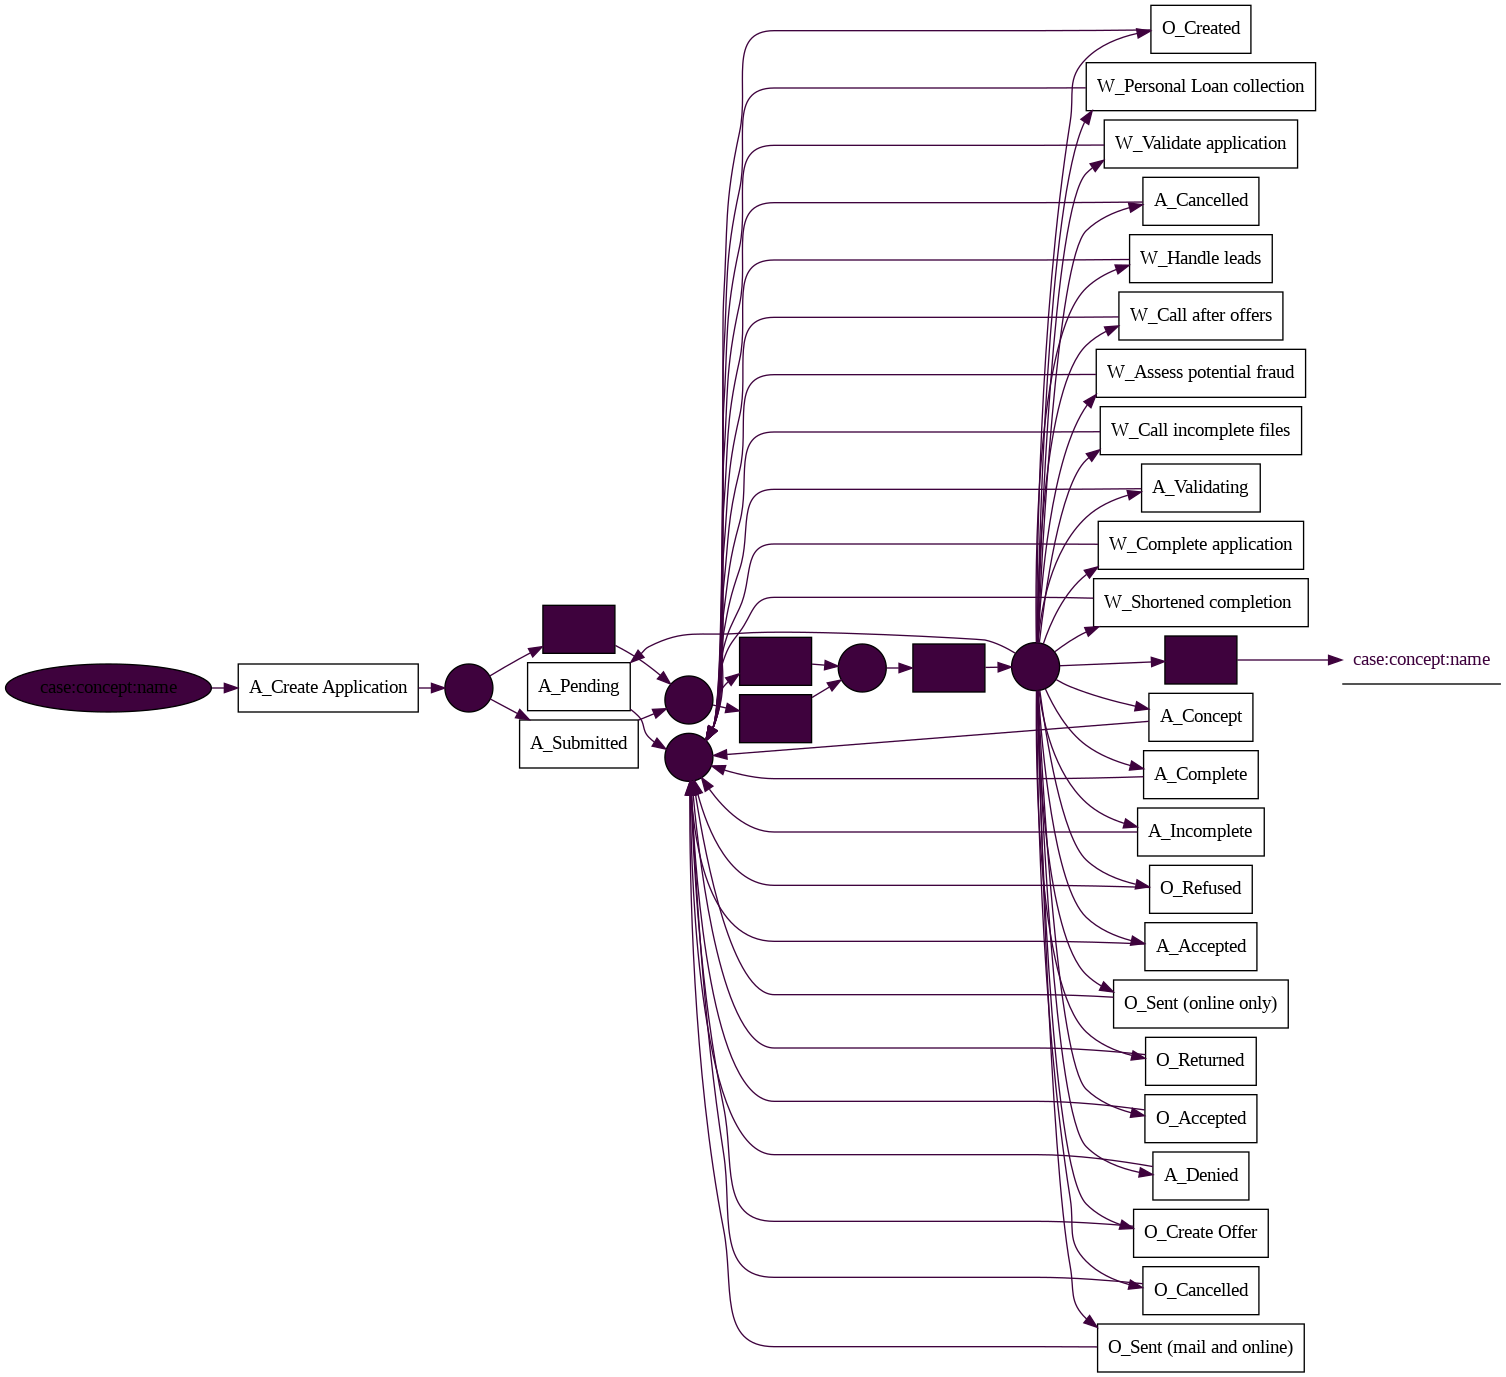

In [37]:
gviz = ocpn_visualizer.apply(ocpn)
ocpn_visualizer.view(gviz)

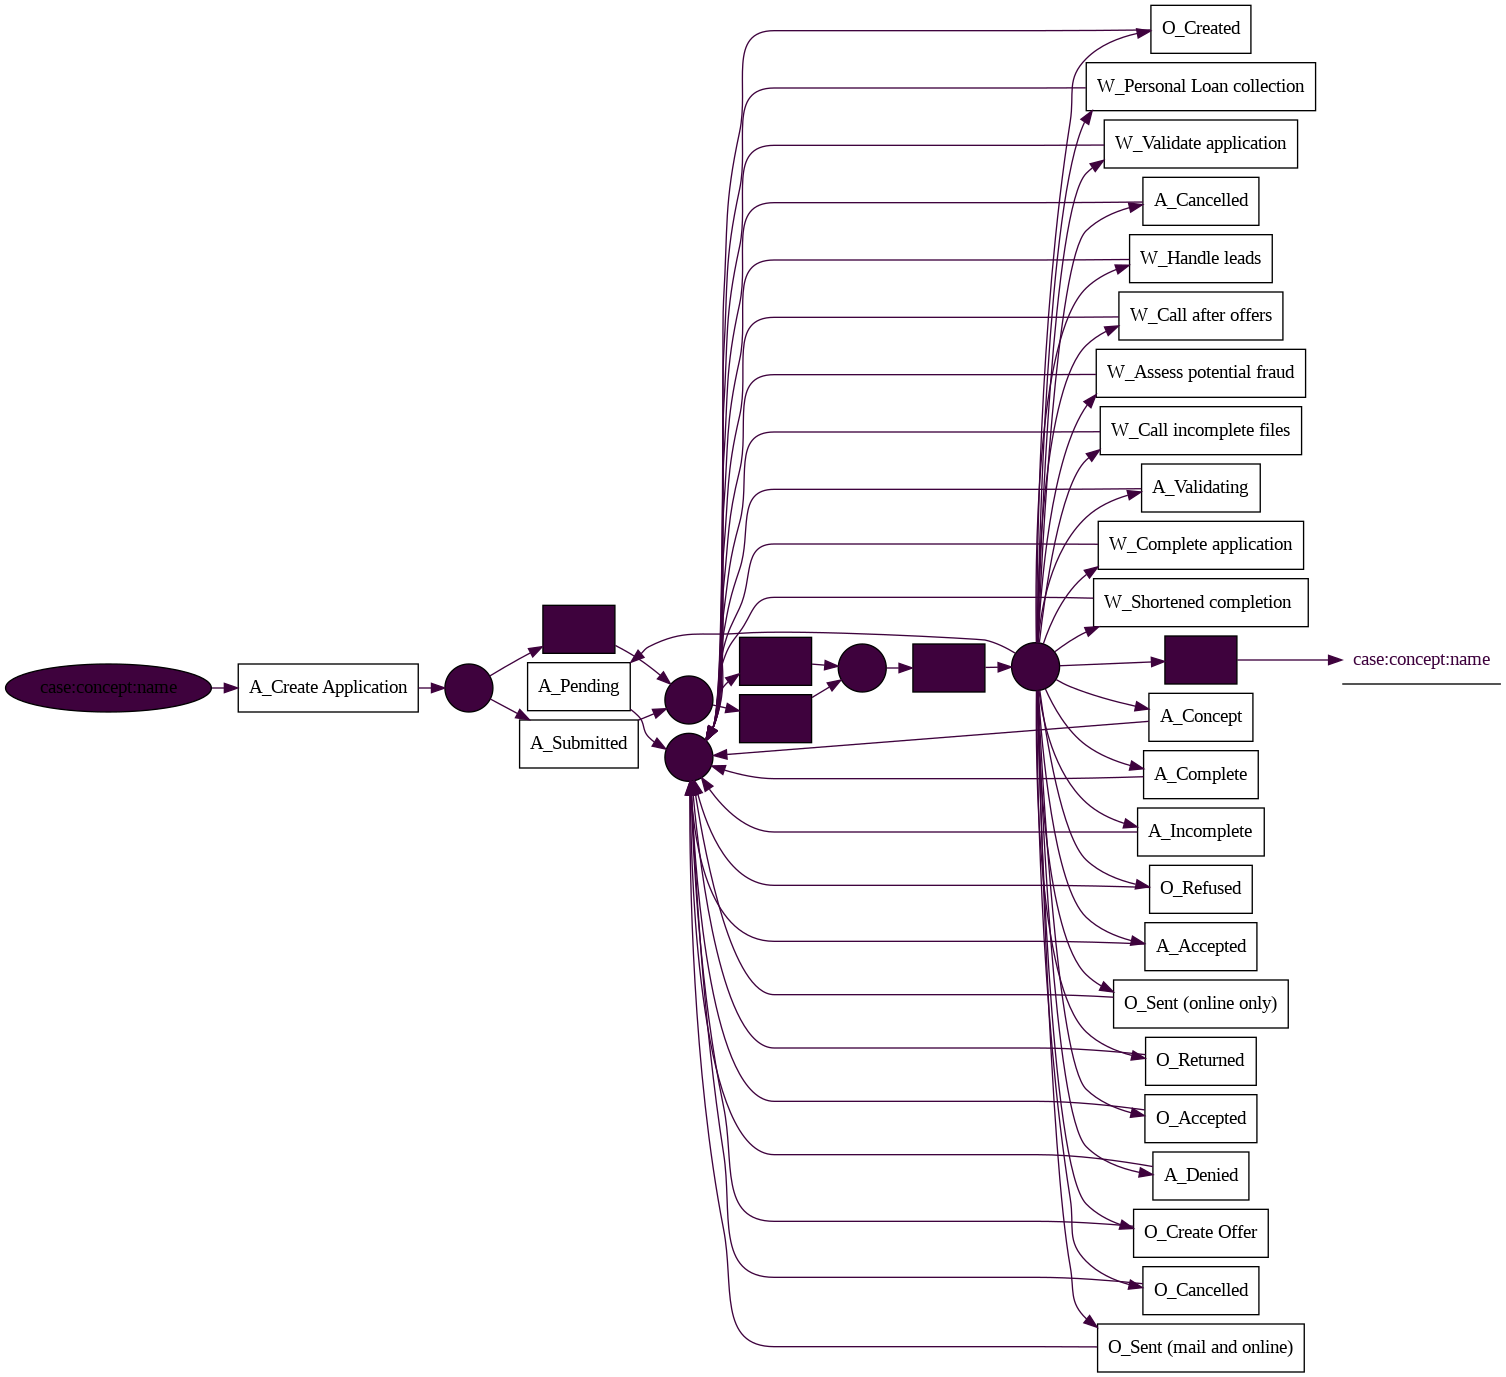

''

In [36]:
gviz = ocpn_visualizer.apply(ocpn)

# Display
ocpn_visualizer.view(gviz)

# Save
ocpn_visualizer.save(gviz, "OCPN_BPI2017_Model.png")